__Pandas DataFrame__

In [1]:
import pandas as pd

In [8]:
rel_path = '../../course_assignments/homework8/state_data.csv'
df = pd.read_csv(rel_path)

In [13]:
print(df.shape)
print(f'There are {df.shape[0]} rows and {df.shape[1]} columns')

(52, 4)
There are 52 rows and 4 columns


In [16]:
print(df.head())
print()
print(df.tail())

  state   latitude   longitude        name
0    AK  63.588753 -154.493062      Alaska
1    AL  32.318231  -86.902298     Alabama
2    AR  35.201050  -91.831833    Arkansas
3    AZ  34.048928 -111.093731     Arizona
4    CA  36.778261 -119.417932  California

   state   latitude   longitude           name
47    VT  44.558803  -72.577841        Vermont
48    WA  47.751074 -120.740139     Washington
49    WI  43.784440  -88.787868      Wisconsin
50    WV  38.597626  -80.454903  West Virginia
51    WY  43.075968 -107.290284        Wyoming


- Explain what the different columns represent.
  
    Each columns represents a different piece of information for each state.
  
- What is the first state in the dataset?

    The first state is Alaska (AK).
- What is the last state in the dataset?

    The last state is Wyoming (WY).
- How many entries are there total?

    There are a total of 52 entries.
- Why is there more than 50 states listed?

    There are more than 50 states listed because it includes the US territory of Puerto Rico and the federal district of columbia.

In [33]:
median_lat = df['latitude'].median()
median_lon = df['longitude'].median()
print(f'Median latitude: {median_lati:.2f} \
\nMedian longitude: {median_long:.2f}')

Median latitude: 39.44 
Median longitude: -89.09


In [35]:
df['abs_dist_lat'] = (df['latitude'] - median_lat).abs()
df['abs_dist_lon'] = (df['longitude'] - median_lon).abs()

print(df.shape)
print(f'Rows: {df.shape[0]} \
\nColumns: {df.shape[1]}')

(52, 6)
Rows: 52 
Columns: 6


In [39]:
closest_lat = df.loc[df['abs_dist_lat'].idxmin()]
print(f"Closest to median latitude: {closest_lat['name']} by {closest_lat['abs_dist_lat']:.2f}")

farthest_lat = df.loc[df['abs_dist_lat'].idxmax()]
print(f"Farthest from median latitude: {farthest_lat['name']} by {farthest_lat['abs_dist_lat']:.2f}")

closest_lon = df.loc[df['abs_dist_lon'].idxmin()]
print(f"Closest to median longitude: {closest_lon['name']} by {closest_lon['abs_dist_lon']:.2f}")

farthest_lon = df.loc[df['abs_dist_lon'].idxmax()]
print(f"Farthest from median longitude: {farthest_lon['name']} by {farthest_lon['abs_dist_lon']:.2f}")

Closest to median latitude: Colorado by 0.11
Farthest from median latitude: Alaska by 24.15
Closest to median longitude: Illinois by 0.31
Farthest from median longitude: Hawaii by 66.57


In [46]:
df_sorted = df.sort_values(by='name')
print(df_sorted.head(10))
print('Found here: https://pandas.pydata.org/docs/user_guide/basics.html#sorting')
print('\nUseful if you want to: \nQuickly find the largest/smallest values in a column, \
\nOrder your data for reporting, plotting, or analysis, \nCompare relative rankings within the data')

  state   latitude   longitude                  name  abs_dist_lat  \
1    AL  32.318231  -86.902298               Alabama      7.117285   
0    AK  63.588753 -154.493062                Alaska     24.153237   
3    AZ  34.048928 -111.093731               Arizona      5.386588   
2    AR  35.201050  -91.831833              Arkansas      4.234465   
4    CA  36.778261 -119.417932            California      2.657255   
5    CO  39.550051 -105.782067              Colorado      0.114536   
6    CT  41.603221  -73.087749           Connecticut      2.167705   
8    DE  38.910832  -75.527670              Delaware      0.524684   
7    DC  38.905985  -77.033418  District of Columbia      0.529530   
9    FL  27.664827  -81.515754               Florida     11.770689   

   abs_dist_lon  
1      2.190900  
0     65.399864  
3     22.000533  
2      2.738635  
4     30.324734  
5     16.688869  
6     16.005449  
8     13.565528  
7     12.059780  
9      7.577444  
Found here: https://pandas.pyda

__Seaborn__

In [107]:
import seaborn as sns
import matplotlib.pyplot as plt

In [158]:
data = pd.DataFrame(sns.load_dataset('geyser'))

In [161]:
data = data.dropna(axis=1)

In [162]:
print('Shape:', data.shape)

print(f'\nRows: {data.shape[0]} \
        \nColumns: {data.shape[1]}')

print(f'\nFirst 5 rows:\n {data.head()}')

print(f'\nLast 5 rows: {data.tail()}')

print('\nColumns and their description:')
for col in data.columns:
    print(col)

Shape: (272, 3)

Rows: 272         
Columns: 3

First 5 rows:
    duration  waiting   kind
0     3.600       79   long
1     1.800       54  short
2     3.333       74   long
3     2.283       62  short
4     4.533       85   long

Last 5 rows:      duration  waiting   kind
267     4.117       81   long
268     2.150       46  short
269     4.417       90   long
270     1.817       46  short
271     4.467       74   long

Columns and their description:
duration
waiting
kind


duration = the duration of the eruption

waiting = time until next eruption

kind = the kind of geyser it is

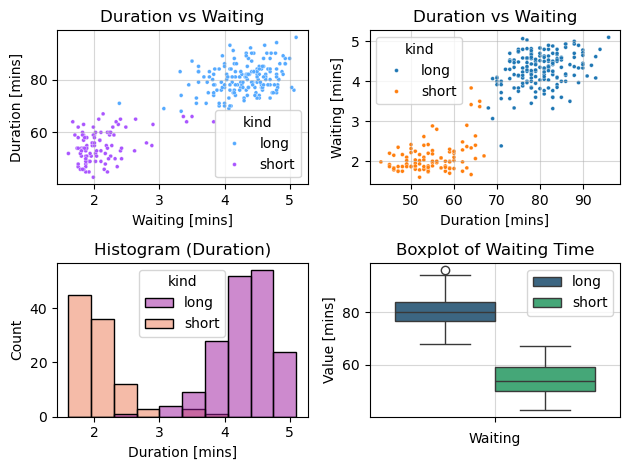

In [201]:
fig, axs = plt.subplots(2, 2)

x = data['duration']
y = data['waiting']

# Top-left scatter plot
ax=axs[0,0]
sns.scatterplot(data=data, x=x, y=y, s=8, hue='kind', palette='cool', ax=ax)
ax.set_title('Duration vs Waiting')
ax.set_xlabel('Waiting [mins]')
ax.set_ylabel('Duration [mins]')
ax.grid(alpha=0.5)

# Top-left scatter plot
ax=axs[0,1]
sns.scatterplot(data=data, x=y, y=x, s=8, hue='kind', ax=ax)
ax.set_title('Duration vs Waiting')
ax.set_xlabel('Duration [mins]')
ax.set_ylabel('Waiting [mins]')
ax.grid(alpha=0.5)

# Bottom-left histogram
ax=axs[1,0]
sns.histplot(data=data, x=x, hue='kind', palette='plasma', ax=ax)
ax.set_title('Histogram (Duration)')
ax.set_xlabel('Duration [mins]')
ax.set_ylabel('Count')

# Bottom-right boxplot
ax=axs[1, 1]
sns.boxplot(data=data, y=y, hue='kind', palette='viridis', ax=ax)
ax.set_title('Boxplot of Waiting Time')
ax.set_xlabel('Waiting')
ax.set_ylabel('Value [mins]')
ax.grid(alpha=0.5)

plt.legend()
plt.tight_layout()
plt.show()

The top-left subplot represents how the duation and waiting times of the geyser eruptions are related, and they are colored by whether the eruption was a long or short one. Shows the eruption kinds are distinct within this space. 

The top-right subplot shows the same plot as the top-left ones, but witht he axes swapped. I did this because there werent enough columns to select entirely new ones. Shows the same as before.

The bottom-left subplot shows a histogram of the duration of the eruptions, which gives us an idea of the distrubution of the duration most/least prevalent values. Shows us that most short eruption are around 2 mins, while most long eruption are around 4.5 mins.

The bottom-right subplot shows the boxplot of the waiting times statistical breakdown. SHows us that the average long waiting time is around 80 mins, and the average short waiting time is around 55 mins.